# EDA Setelah Labeling

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from itertools import islice
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = '../data/processed/labeled_comments_kopdes.parquet'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f'File {DATA_PATH} belum ada.\n'
        'Jalankan dulu 06_sentiment_labeling_indobert.ipynb di Google Colab, '
        'lalu simpan hasilnya ke folder data/processed/ sebelum menjalankan notebook ini.'
    )

df = pd.read_parquet(DATA_PATH)
print(f'Baris data berlabel: {len(df):,}')
assert set(df['sentiment_label'].unique()) <= {'positive', 'neutral', 'negative'}, \
    'Ditemukan label di luar 3 kelas standar - cek ulang Tahap 6.'
df[['comment', 'sentiment_label', 'sentiment_confidence']].head(5)

Baris data berlabel: 119,565


,comment,sentiment_label,sentiment_confidence
0,Beliau bilang untung nya 2 m ?,positive,0.9889
1,Makasih Mas,positive,0.9756
2,Gimana untung nya 2 m..barang yg di jual ajh ga ada 1 m 😁,negative,0.8542
3,[Sticker] dibilang Makasih Mas udah 2M itu,neutral,0.7167
4,"Kalo niat membantu UMKM, harusnya koprasi merah putih dibuka dalam bentuk warehouse (gudang), bu...",positive,0.7584


## Menggabungkan dengan Teks Terstem (Tahap 5)

In [101]:
df_prep = pd.read_parquet('../data/interim/preprocessed_comments_kopdes.parquet')[['video_id','comment_id','text_final']]

df_merged = df.merge(df_prep, on=['video_id','comment_id'], how='inner')
print(f'Baris setelah merge dgn text_final: {len(df_merged):,} (dari {len(df):,} baris berlabel)')
df_merged[['comment', 'text_final', 'sentiment_label']].head(3)

Baris setelah merge dgn text_final: 118,778 (dari 119,565 baris berlabel)


,comment,text_final,sentiment_label
0,Beliau bilang untung nya 2 m ?,beliau bilang untung,positive
1,Makasih Mas,makasih mas,positive
2,Gimana untung nya 2 m..barang yg di jual ajh ga ada 1 m 😁,untung barang jual ajh,negative


## Distribusi Sentimen

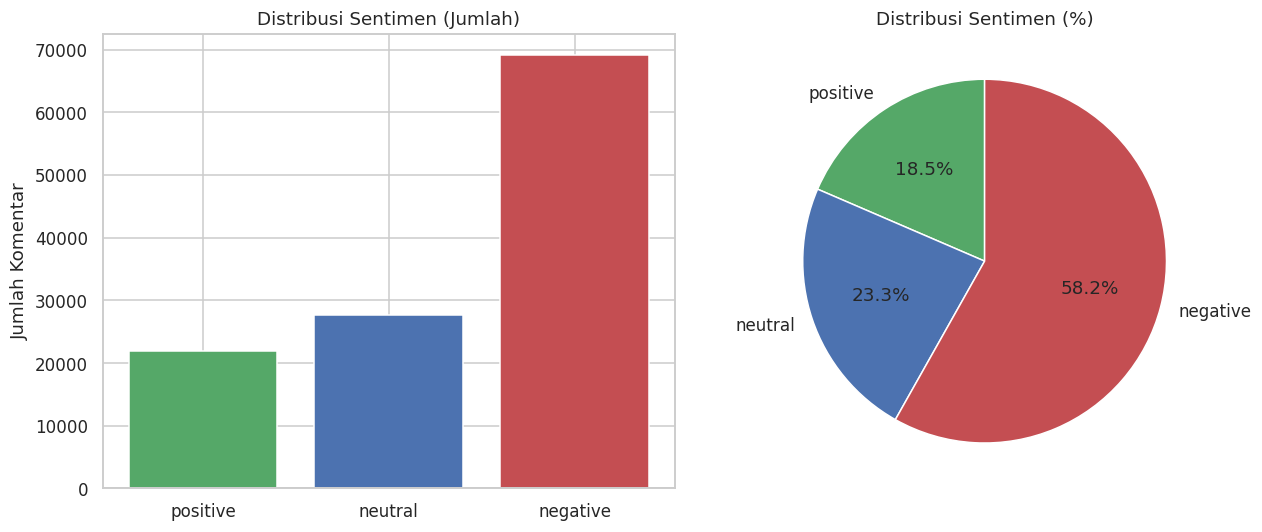

sentiment_label
negative    69083
neutral     27692
positive    22003
Name: count, dtype: int64

sentiment_label
negative    58.16
neutral     23.31
positive    18.52
Name: proportion, dtype: float64


In [102]:
dist = df_merged['sentiment_label'].value_counts()
dist_pct = df_merged['sentiment_label'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {'positive': '#55A868', 'neutral': '#4C72B0', 'negative': '#C44E52'}
order = ['positive', 'neutral', 'negative']
bar_colors = [colors[l] for l in order]

axes[0].bar(order, [dist.get(l, 0) for l in order], color=bar_colors)
axes[0].set_title('Distribusi Sentimen (Jumlah)')
axes[0].set_ylabel('Jumlah Komentar')

axes[1].pie([dist.get(l, 0) for l in order], labels=order, autopct='%1.1f%%',
            colors=bar_colors, startangle=90)
axes[1].set_title('Distribusi Sentimen (%)')

plt.tight_layout()
plt.savefig('../reports/figures/08_sentiment_distribution.png', bbox_inches='tight')
plt.show()

print(dist)
print()
print(dist_pct.round(2))

## Distribusi Confidence Score per Kelas Sentimen

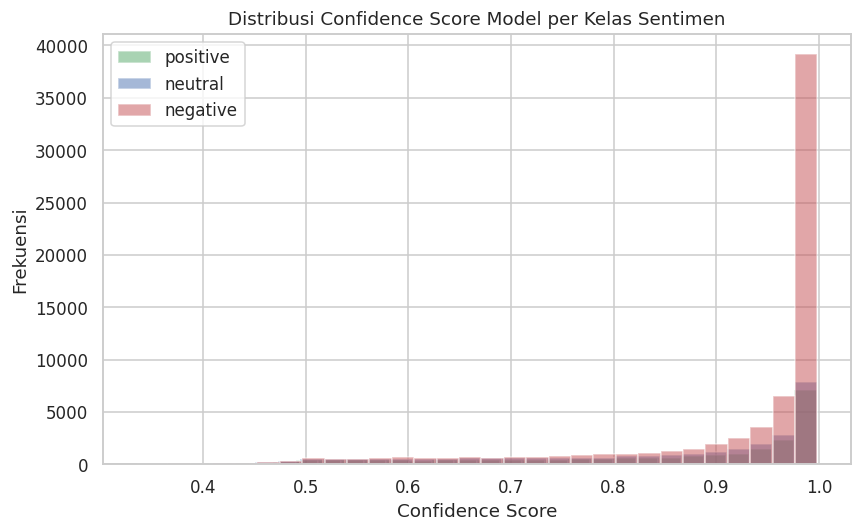

Baris dengan confidence < 0.6: 9,951 (8.38%) - kandidat audit manual


In [103]:
fig, ax = plt.subplots(figsize=(8, 5))
for label in order:
    subset = df_merged[df_merged['sentiment_label'] == label]['sentiment_confidence']
    ax.hist(subset, bins=30, alpha=0.5, label=label, color=colors[label])
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Confidence Score Model per Kelas Sentimen')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/09_confidence_by_class.png', bbox_inches='tight')
plt.show()

low_conf = df_merged[df_merged['sentiment_confidence'] < 0.6]
print(f'Baris dengan confidence < 0.6: {len(low_conf):,} ({len(low_conf)/len(df_merged)*100:.2f}%) - kandidat audit manual')

## WordCloud Positive

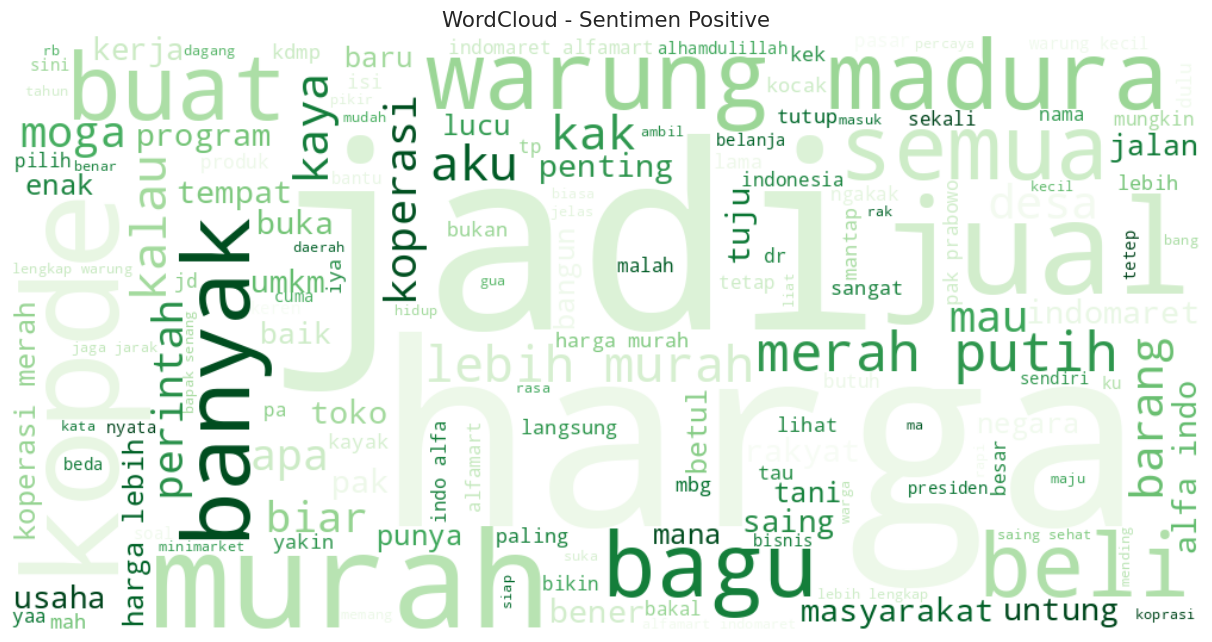

In [104]:
text_positive = ' '.join(df_merged.loc[df_merged['sentiment_label']=='positive', 'text_final'])

wc_pos = WordCloud(width=1000, height=500, background_color='white',
                    colormap='Greens', max_words=150).generate(text_positive)

plt.figure(figsize=(12, 6))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Sentimen Positive', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/10_wordcloud_positive.png', bbox_inches='tight')
plt.show()

## WordCloud Negative

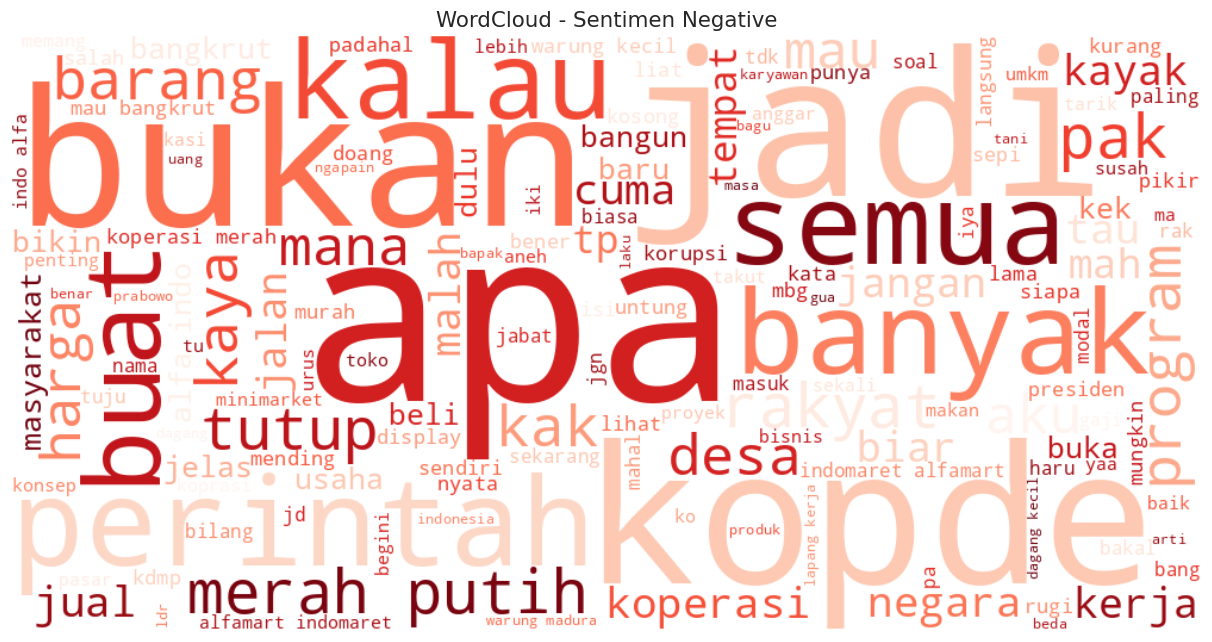

In [105]:
text_negative = ' '.join(df_merged.loc[df_merged['sentiment_label']=='negative', 'text_final'])

wc_neg = WordCloud(width=1000, height=500, background_color='white',
                    colormap='Reds', max_words=150).generate(text_negative)

plt.figure(figsize=(12, 6))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Sentimen Negative', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/11_wordcloud_negative.png', bbox_inches='tight')
plt.show()

## WordCloud Neutral (tambahan, untuk kelengkapan 3 kelas)

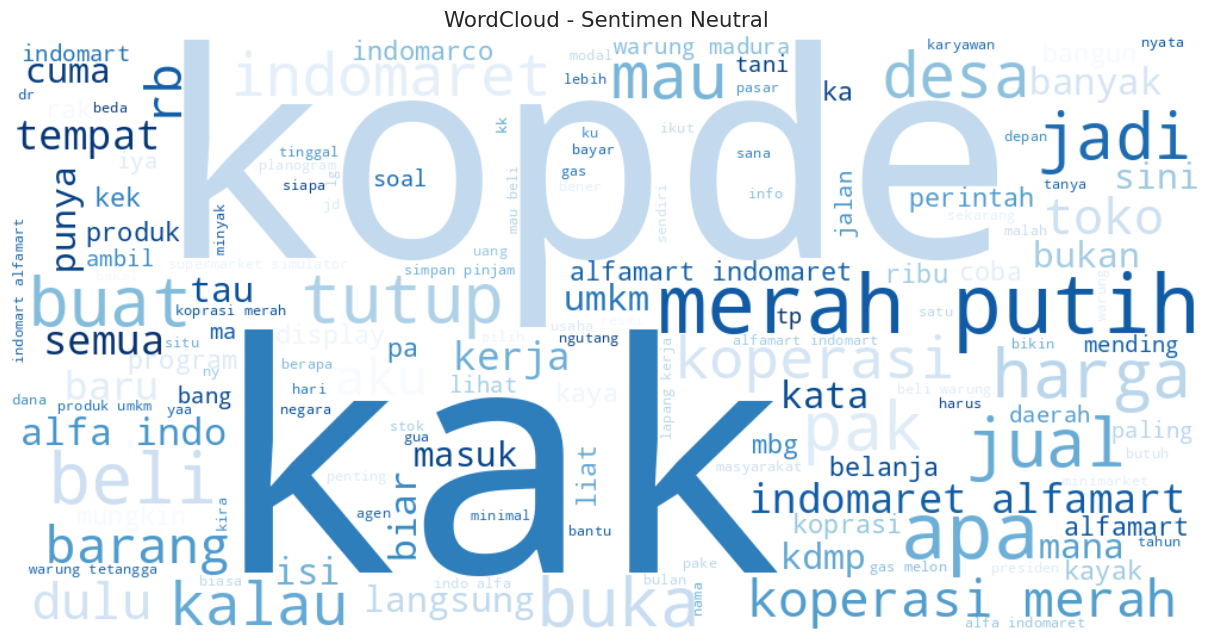

In [106]:
text_neutral = ' '.join(df_merged.loc[df_merged['sentiment_label']=='neutral', 'text_final'])

wc_neu = WordCloud(width=1000, height=500, background_color='white',
                    colormap='Blues', max_words=150).generate(text_neutral)

plt.figure(figsize=(12, 6))
plt.imshow(wc_neu, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Sentimen Neutral', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/12_wordcloud_neutral.png', bbox_inches='tight')
plt.show()

## Top Frequent Words (Keseluruhan & per Kelas)

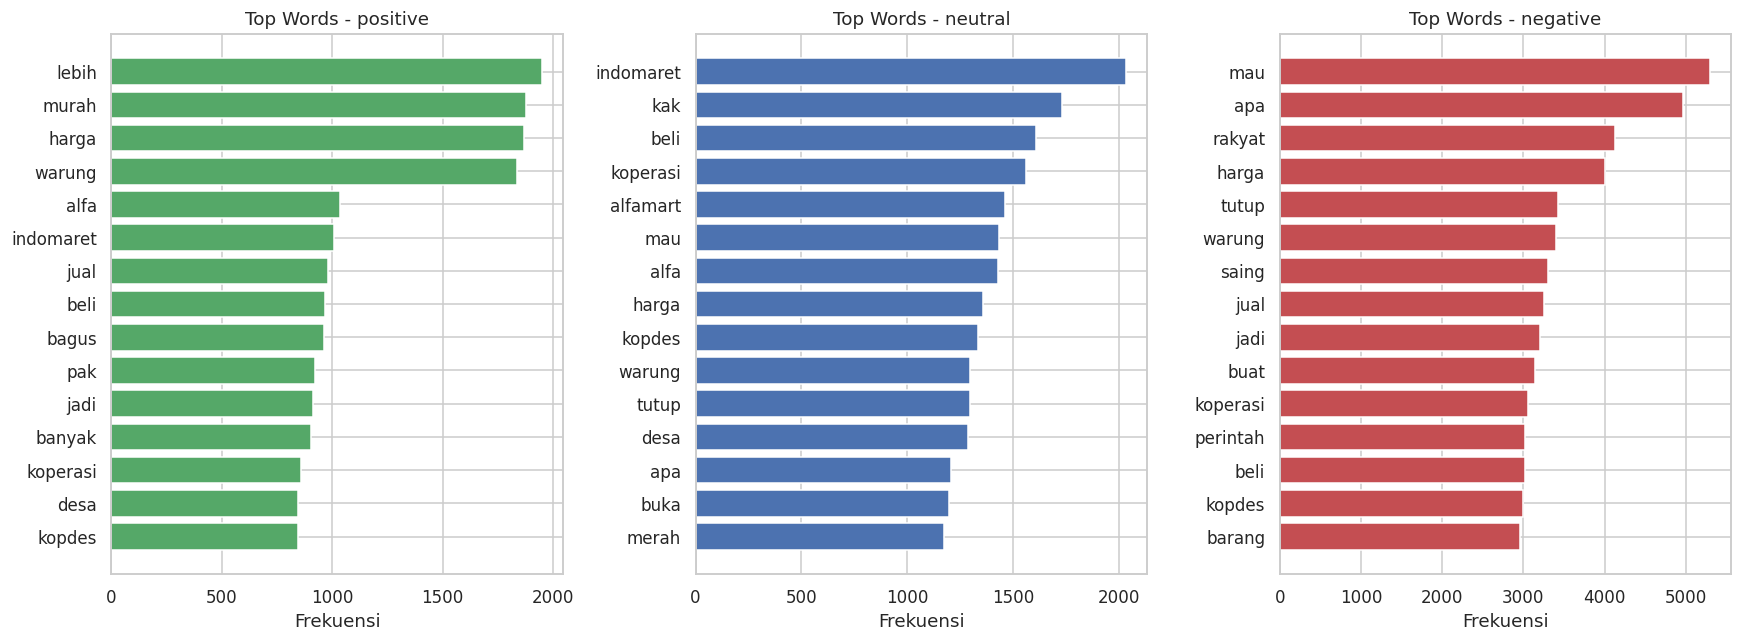

In [107]:
def top_words(text_series, n=20):
    counter = Counter()
    for t in text_series:
        counter.update(t.split())
    return counter.most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, label in zip(axes, order):
    subset = df_merged.loc[df_merged['sentiment_label']==label, 'text_final']
    tw = top_words(subset, 15)
    words, counts = zip(*tw) if tw else ([], [])
    ax.barh(words[::-1], counts[::-1], color=colors[label])
    ax.set_title(f'Top Words - {label}')
    ax.set_xlabel('Frekuensi')

plt.tight_layout()
plt.savefig('../reports/figures/13_top_words_per_class.png', bbox_inches='tight')
plt.show()

## Bigram & Trigram Analysis

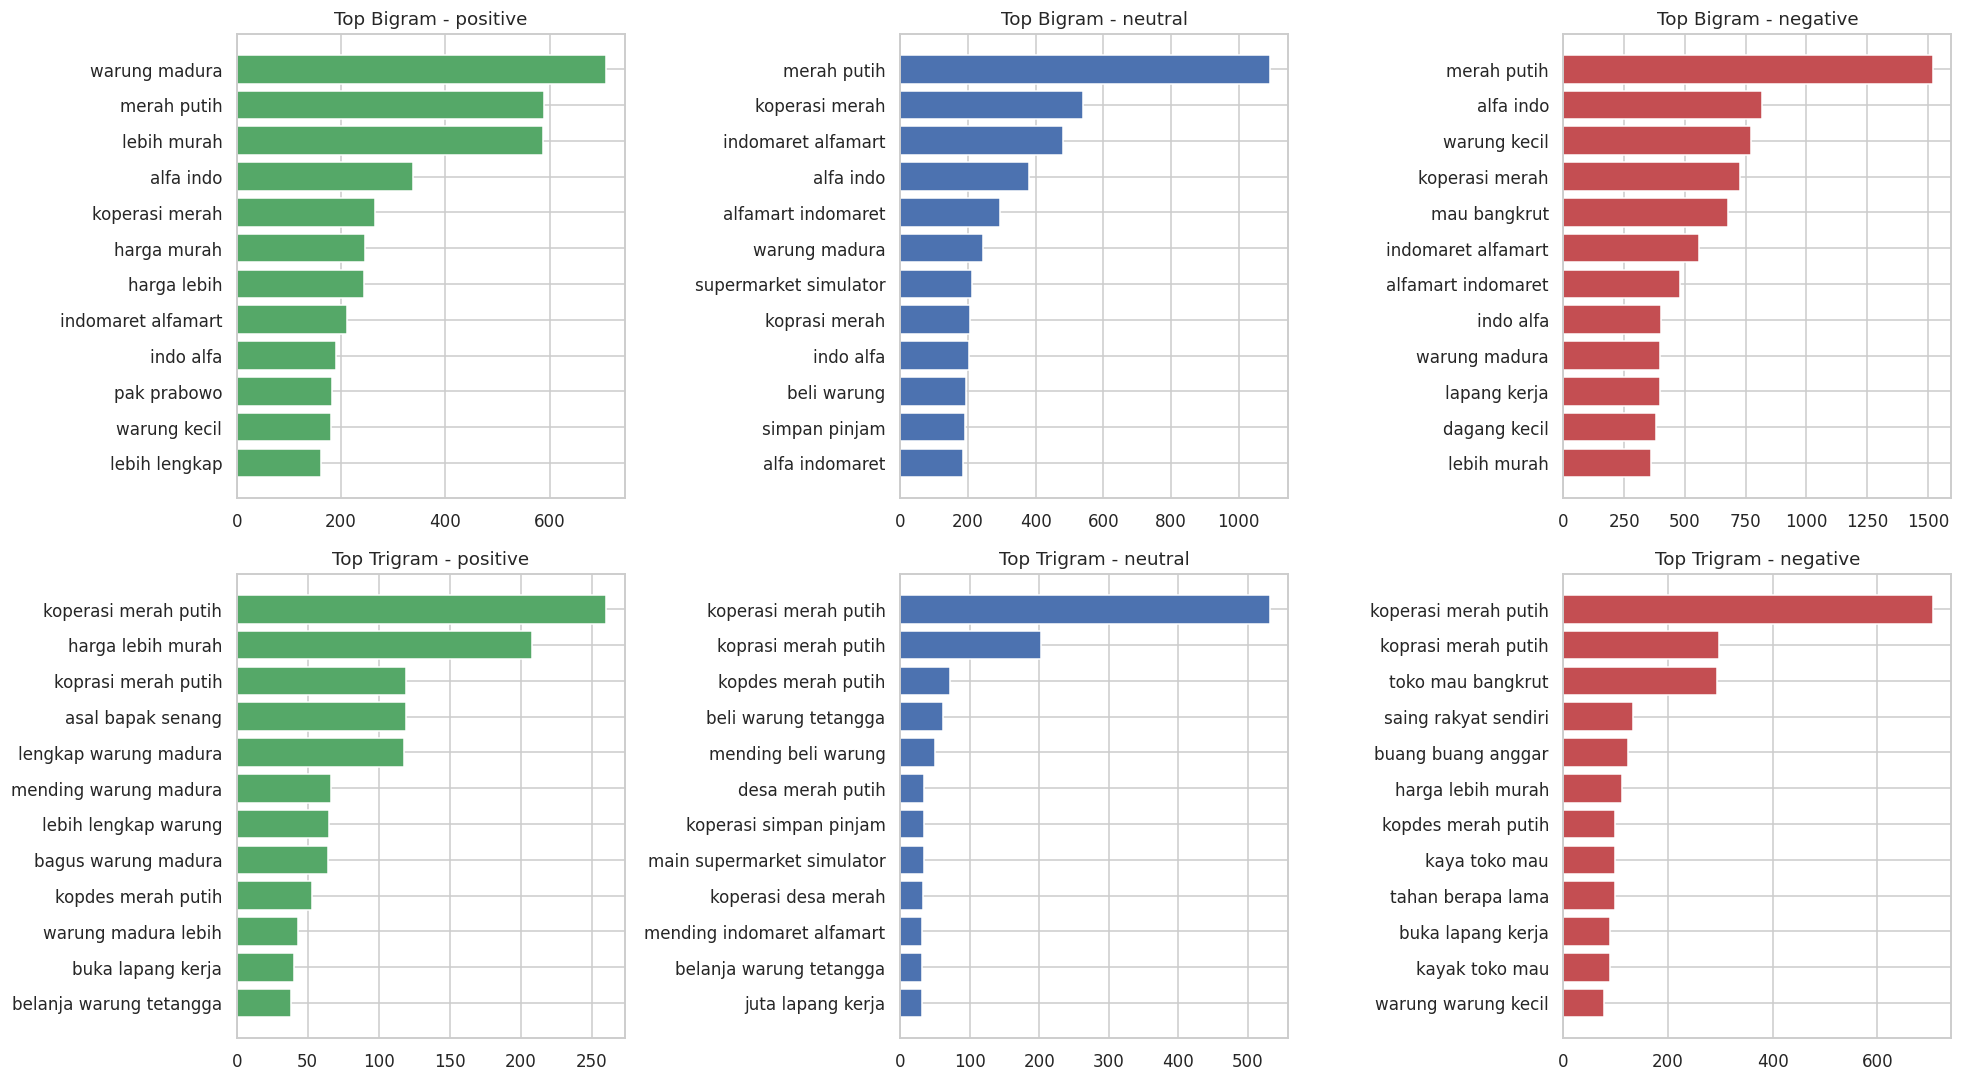

In [108]:
def get_ngrams(text_series, n=2, top_k=15):
    counter = Counter()
    for t in text_series:
        tokens = t.split()
        ngrams = zip(*[islice(tokens, i, None) for i in range(n)])
        counter.update([' '.join(g) for g in ngrams])
    return counter.most_common(top_k)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for col, label in enumerate(order):
    subset = df_merged.loc[df_merged['sentiment_label']==label, 'text_final']

    bigrams = get_ngrams(subset, n=2, top_k=12)
    if bigrams:
        words, counts = zip(*bigrams)
        axes[0, col].barh(words[::-1], counts[::-1], color=colors[label])
    axes[0, col].set_title(f'Top Bigram - {label}')

    trigrams = get_ngrams(subset, n=3, top_k=12)
    if trigrams:
        words, counts = zip(*trigrams)
        axes[1, col].barh(words[::-1], counts[::-1], color=colors[label])
    axes[1, col].set_title(f'Top Trigram - {label}')

plt.tight_layout()
plt.savefig('../reports/figures/14_bigram_trigram.png', bbox_inches='tight')
plt.show()

## Sentimen per Video & Tren Waktu

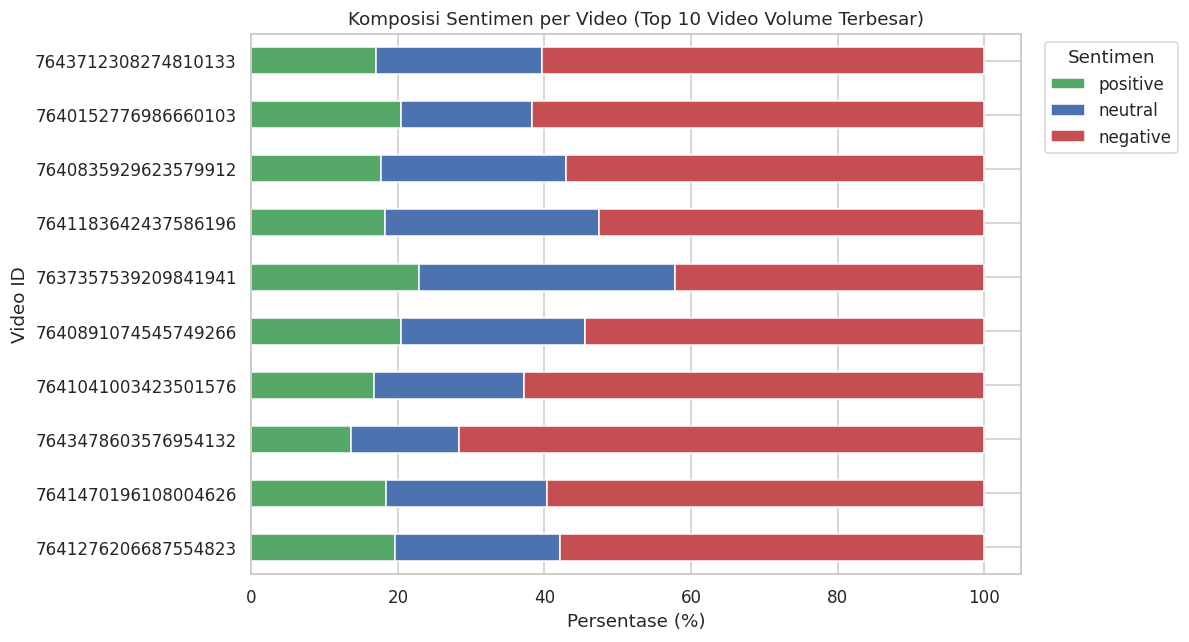

In [109]:
sentiment_by_video = pd.crosstab(df_merged['video_id'], df_merged['sentiment_label'], normalize='index') * 100
top_videos_by_volume = df_merged['video_id'].value_counts().head(10).index
sentiment_by_video_top = sentiment_by_video.loc[top_videos_by_volume][order]

fig, ax = plt.subplots(figsize=(11, 6))
sentiment_by_video_top.plot(kind='barh', stacked=True, color=[colors[l] for l in order], ax=ax)
ax.set_xlabel('Persentase (%)')
ax.set_ylabel('Video ID')
ax.set_title('Komposisi Sentimen per Video (Top 10 Video Volume Terbesar)')
ax.legend(title='Sentimen', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../reports/figures/15_sentiment_by_video.png', bbox_inches='tight')
plt.show()

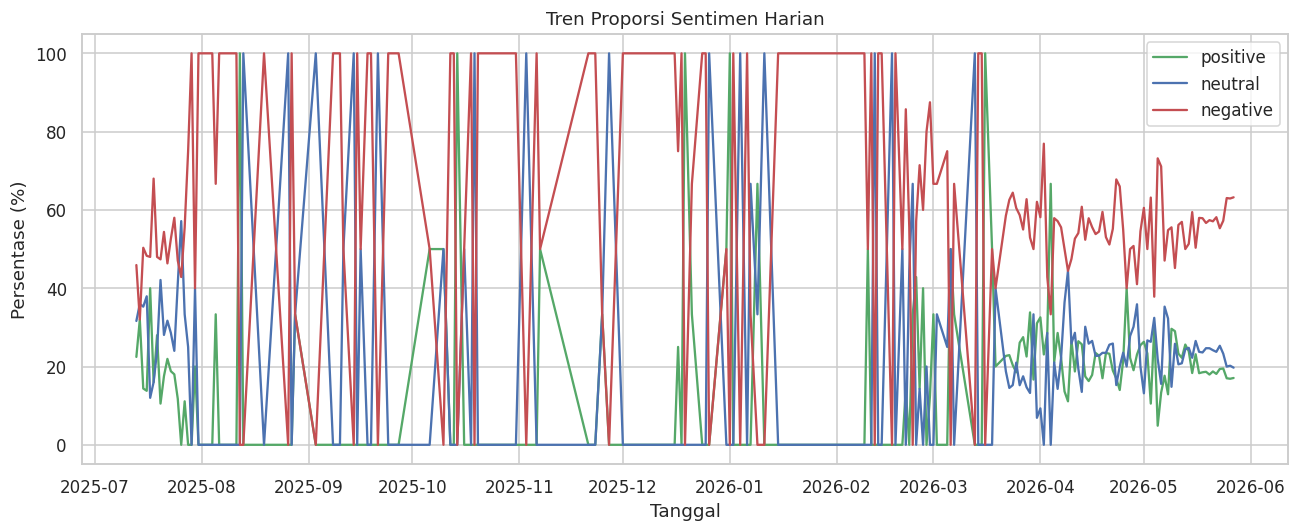

In [110]:
df_merged['date'] = pd.to_datetime(df_merged['create_time']).dt.date
daily_sentiment = df_merged.groupby(['date', 'sentiment_label']).size().unstack(fill_value=0)
daily_sentiment = daily_sentiment.reindex(columns=order, fill_value=0)
daily_sentiment_pct = daily_sentiment.div(daily_sentiment.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
for label in order:
    ax.plot(daily_sentiment_pct.index, daily_sentiment_pct[label], label=label, color=colors[label])
ax.set_title('Tren Proporsi Sentimen Harian')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Persentase (%)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/16_sentiment_trend.png', bbox_inches='tight')
plt.show()

### Kesimpulan EDA Setelah Labeling

Isi bagian ini **setelah menjalankan notebook dengan data label asli** dari Tahap 6:
- Proporsi Positive/Neutral/Negative dan interpretasinya terhadap opini publik soal Kopdes
- Kata/frasa dominan tiap kelas sentimen dari WordCloud & Top Words
- Bigram/trigram yang mengindikasikan topik spesifik keluhan/dukungan
- Video mana yang paling positif/negatif responnya
- Apakah ada tren sentimen berubah dari waktu ke waktu (mis. makin negatif setelah insiden tertentu)
- Baris dengan confidence rendah (<0.6) — pertimbangkan audit manual sebelum lanjut ke modeling

**Status: kode Tahap 7 (EDA Setelah Labeling) selesai & siap pakai.** Menunggu file
`labeled_comments_kopdes.parquet` dari Tahap 6 (Colab) untuk dijalankan dan menghasilkan
insight aktual. Setelah itu, lanjut ke **Tahap 8: Feature Engineering (TF-IDF)**.